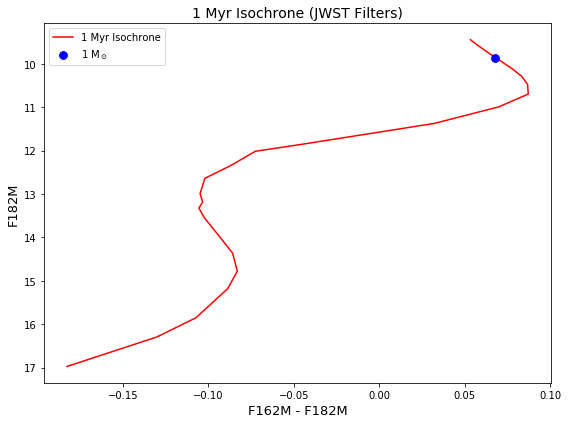

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from spisea import synthetic, evolution, atmospheres, reddening

# --- Parameters ---
AKs = 0                      # No extinction
dist = 410                   # pc
metallicity = 0              # solar metallicity
log_age = np.log10(1e6)      # 1 Myr = 1e6 yr
evo_model = evolution.Baraffe15()
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawHosek18b()
iso_dir = 'isochrones/'

# JWST filter list
filt_list = ['jwst,F162M', 'jwst,F182M']
filters = ['m_jwst_F162M', 'm_jwst_F182M']

# --- Generate isochrone ---
iso = synthetic.IsochronePhot(
    log_age, AKs, dist,
    metallicity=metallicity,
    evo_model=evo_model,
    atm_func=atm_func,
    red_law=red_law,
    filters=filt_list,
    iso_dir=iso_dir
)

# --- Extract magnitudes ---
color = iso.points[filters[0]] - iso.points[filters[1]]
mag = iso.points[filters[1]]

# --- Plot isochrone ---
plt.figure(figsize=(8, 6))
plt.plot(color, mag, color='red', lw=1.5, label='1 Myr Isochrone')
plt.gca().invert_yaxis()

# --- Highlight 1 Msun point ---
mass_arr = iso.points['mass']
# find index closest to 1 Msun
idx_1Msun = np.argmin(np.abs(mass_arr - 1.0))
plt.scatter(color[idx_1Msun], mag[idx_1Msun],
            color='blue', s=60, zorder=5,
            label='1 M$_\odot$')

# --- Labels and styling ---
plt.xlabel('F162M - F182M', fontsize=13)
plt.ylabel('F182M', fontsize=13)
plt.title('1 Myr Isochrone (JWST Filters)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

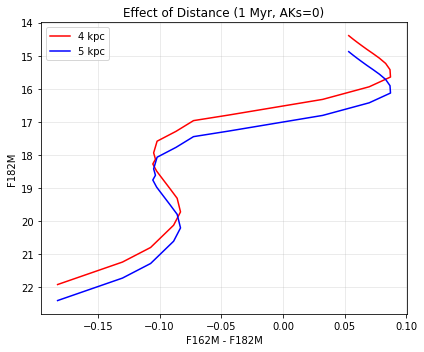

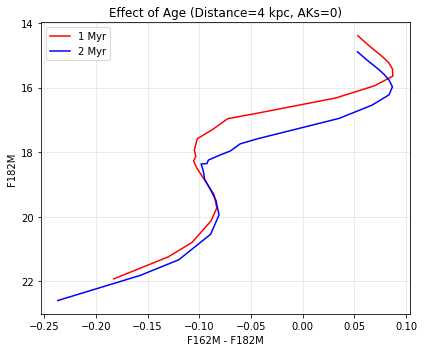

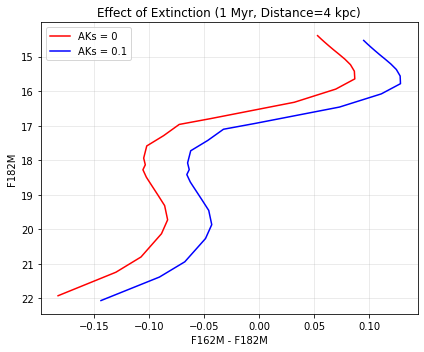

In [12]:
metallicity = 0
dist_base = 4000   # pc
AKs_base = 0
log_age_base = np.log10(1e6)  # 1 Myr
evo_model = evolution.Baraffe15()
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawHosek18b()
iso_dir = 'isochrones/'
filt_list = ['jwst,F162M', 'jwst,F182M']
filters = ['m_jwst_F162M', 'm_jwst_F182M']

def make_iso(log_age, AKs, dist):
    return synthetic.IsochronePhot(log_age, AKs, dist,
                                   metallicity=metallicity,
                                   evo_model=evo_model,
                                   atm_func=atm_func,
                                   red_law=red_law,
                                   filters=filt_list,
                                   iso_dir=iso_dir)

def plot_before_after(ax, iso1, iso2, label1, label2):
    """Generic before-after plotting function"""
    color1 = iso1.points[filters[0]] - iso1.points[filters[1]]
    mag1   = iso1.points[filters[1]]
    color2 = iso2.points[filters[0]] - iso2.points[filters[1]]
    mag2   = iso2.points[filters[1]]
    ax.plot(color1, mag1, color='red', lw=1.5, label=label1)
    ax.plot(color2, mag2, color='blue', lw=1.5, label=label2)
    ax.invert_yaxis()
    ax.set_xlabel('F162M - F182M')
    ax.set_ylabel('F182M')
    ax.legend()
    ax.grid(True, alpha=0.3)

# --- 1. Distance comparison (4 kpc vs 5 kpc) ---
iso_d1 = make_iso(log_age_base, AKs_base, 4000)
iso_d2 = make_iso(log_age_base, AKs_base, 5000)

fig, ax = plt.subplots(figsize=(6,5))
plot_before_after(ax, iso_d1, iso_d2, '4 kpc', '5 kpc')
ax.set_title('Effect of Distance (1 Myr, AKs=0)')
plt.tight_layout()
plt.show()

# --- 2. Age comparison (1 Myr vs 2 Myr) ---
iso_a1 = make_iso(np.log10(1e6), AKs_base, dist_base)
iso_a2 = make_iso(np.log10(2e6), AKs_base, dist_base)

fig, ax = plt.subplots(figsize=(6,5))
plot_before_after(ax, iso_a1, iso_a2, '1 Myr', '2 Myr')
ax.set_title('Effect of Age (Distance=4 kpc, AKs=0)')
plt.tight_layout()
plt.show()

# --- 3. Extinction comparison (AKs=0 vs AKs=5) ---
iso_e1 = make_iso(log_age_base, 0, dist_base)
iso_e2 = make_iso(log_age_base, 0.1, dist_base)

fig, ax = plt.subplots(figsize=(6,5))
plot_before_after(ax, iso_e1, iso_e2, 'AKs = 0', 'AKs = 0.1')
ax.set_title('Effect of Extinction (1 Myr, Distance=4 kpc)')
plt.tight_layout()
plt.show()

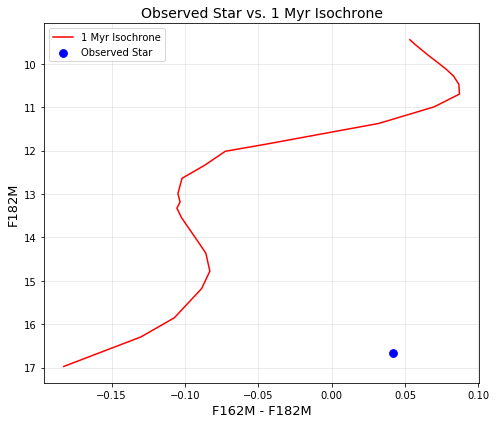

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from spisea import synthetic, evolution, atmospheres, reddening

# --- Load first row of observed data ---
file_path = '/scratch/wyz5rge/synthetic-hr/notebooks/2025/08-11_morten-chi-squared-cross-reference/winstonlist.dat'
data = np.loadtxt(file_path)
first_row = data[3]

# Columns: x, y, f162, f162_err, f182, f182_err, f200, f200_err, AV, mass
f162 = first_row[2]
f182 = first_row[4]

# --- Define isochrone parameters (1 Myr) ---
AKs = 0
dist = 410  # pc
metallicity = 0
log_age = np.log10(1e6)
evo_model = evolution.Baraffe15()
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawHosek18b()
iso_dir = 'isochrones/'
filt_list = ['jwst,F162M', 'jwst,F182M']
filters = ['m_jwst_F162M', 'm_jwst_F182M']

# --- Generate isochrone ---
iso = synthetic.IsochronePhot(
    log_age, AKs, dist,
    metallicity=metallicity,
    evo_model=evo_model,
    atm_func=atm_func,
    red_law=red_law,
    filters=filt_list,
    iso_dir=iso_dir
)

# --- Plot CMD ---
color = iso.points[filters[0]] - iso.points[filters[1]]
mag = iso.points[filters[1]]

fig, ax = plt.subplots(figsize=(7,6))
ax.plot(color, mag, color='red', lw=1.5, label='1 Myr Isochrone')

# --- Plot observed star (no error bars) ---
obs_color = f162 - f182
ax.scatter(obs_color, f182, color='blue', s=60, label='Observed Star')

# --- Plot formatting ---
ax.set_xlabel('F162M - F182M', fontsize=13)
ax.set_ylabel('F182M', fontsize=13)
ax.set_title('Observed Star vs. 1 Myr Isochrone', fontsize=14)
ax.invert_yaxis()
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Isochrone generation took 1.254673 s.
Making photometry for isochrone: log(t) = 6.00  AKs = 0.41  dist = 410
     Starting at:  2025-10-17 03:05:02.482625   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F162M = 17.52
Starting filter: jwst,F182M   Elapsed time: 0.67 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F182M = 17.54
      Time taken: 1.33 seconds


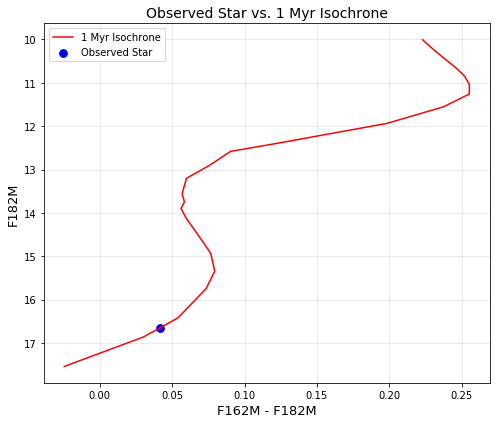

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from spisea import synthetic, evolution, atmospheres, reddening

# --- Load first row of observed data ---
file_path = '/scratch/wyz5rge/synthetic-hr/notebooks/2025/08-11_morten-chi-squared-cross-reference/winstonlist.dat'
data = np.loadtxt(file_path)
first_row = data[3]

# Columns: x, y, f162, f162_err, f182, f182_err, f200, f200_err, AV, mass
f162 = first_row[2]
f182 = first_row[4]

# --- Define isochrone parameters (1 Myr) ---
AKs = 0.405
dist = 410  # pc
metallicity = 0
log_age = np.log10(1e6)
evo_model = evolution.Baraffe15()
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawHosek18b()
iso_dir = 'isochrones/'
filt_list = ['jwst,F162M', 'jwst,F182M']
filters = ['m_jwst_F162M', 'm_jwst_F182M']

# --- Generate isochrone ---
iso = synthetic.IsochronePhot(
    log_age, AKs, dist,
    metallicity=metallicity,
    evo_model=evo_model,
    atm_func=atm_func,
    red_law=red_law,
    filters=filt_list,
    iso_dir=iso_dir
)

# --- Plot CMD ---
color = iso.points[filters[0]] - iso.points[filters[1]]
mag = iso.points[filters[1]]

fig, ax = plt.subplots(figsize=(7,6))
ax.plot(color, mag, color='red', lw=1.5, label='1 Myr Isochrone')

# --- Plot observed star (no error bars) ---
obs_color = f162 - f182
ax.scatter(obs_color, f182, color='blue', s=60, label='Observed Star')

# --- Plot formatting ---
ax.set_xlabel('F162M - F182M', fontsize=13)
ax.set_ylabel('F182M', fontsize=13)
ax.set_title('Observed Star vs. 1 Myr Isochrone', fontsize=14)
ax.invert_yaxis()
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

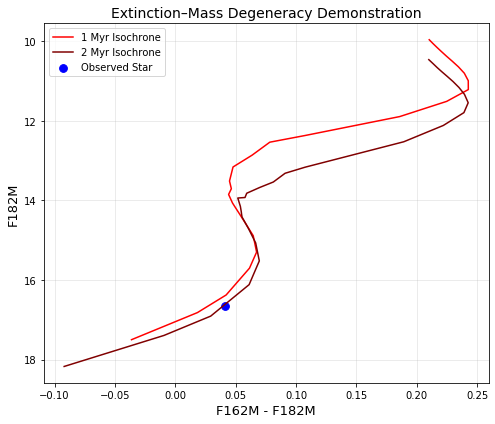

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from spisea import synthetic, evolution, atmospheres, reddening

# --- Load first row of observed data ---
file_path = '/scratch/wyz5rge/synthetic-hr/notebooks/2025/08-11_morten-chi-squared-cross-reference/winstonlist.dat'
data = np.loadtxt(file_path)
first_row = data[3]

# Columns: x, y, f162, f162_err, f182, f182_err, f200, f200_err, AV, mass
f162 = first_row[2]
f182 = first_row[4]

# --- Shared parameters ---
AKs = 0.382
dist = 410  # pc
metallicity = 0
evo_model = evolution.Baraffe15()
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawHosek18b()
iso_dir = 'isochrones/'
filt_list = ['jwst,F162M', 'jwst,F182M']
filters = ['m_jwst_F162M', 'm_jwst_F182M']

# --- Generate 1 Myr and 2 Myr isochrones ---
iso_1myr = synthetic.IsochronePhot(
    np.log10(1e6), AKs, dist,
    metallicity=metallicity,
    evo_model=evo_model,
    atm_func=atm_func,
    red_law=red_law,
    filters=filt_list,
    iso_dir=iso_dir
)

iso_2myr = synthetic.IsochronePhot(
    np.log10(2e6), AKs, dist,
    metallicity=metallicity,
    evo_model=evo_model,
    atm_func=atm_func,
    red_law=red_law,
    filters=filt_list,
    iso_dir=iso_dir
)

# --- Plot CMD ---
fig, ax = plt.subplots(figsize=(7,6))

# 1 Myr Isochrone (red)
color_1 = iso_1myr.points[filters[0]] - iso_1myr.points[filters[1]]
mag_1 = iso_1myr.points[filters[1]]
ax.plot(color_1, mag_1, color='red', lw=1.5, label='1 Myr Isochrone')

# 2 Myr Isochrone (blue)
color_2 = iso_2myr.points[filters[0]] - iso_2myr.points[filters[1]]
mag_2 = iso_2myr.points[filters[1]]
ax.plot(color_2, mag_2, color='maroon', lw=1.5, label='2 Myr Isochrone')

# Observed star
obs_color = f162 - f182
ax.scatter(obs_color, f182, color='blue', s=60, label='Observed Star')

# --- Formatting ---
ax.set_xlabel('F162M - F182M', fontsize=13)
ax.set_ylabel('F182M', fontsize=13)
ax.set_title('Extinction–Mass Degeneracy Demonstration', fontsize=14)
ax.invert_yaxis()
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

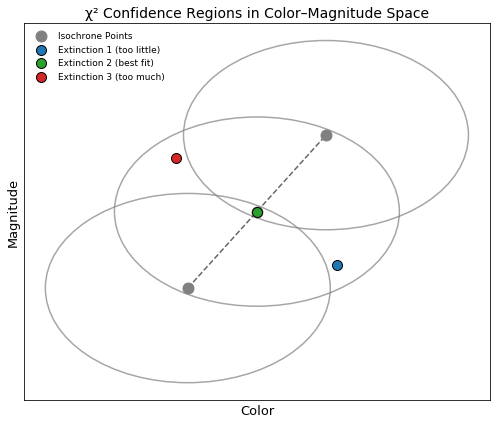

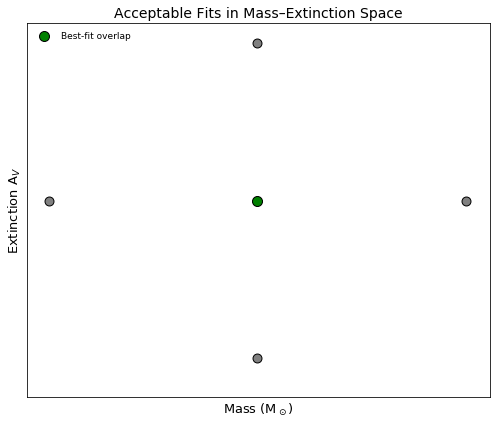

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# 1. Color–Magnitude Space
# ---------------------------

fig, ax = plt.subplots(figsize=(7,6))

# Isochrone points: bottom-left → top-right
iso_x = np.array([0.44, 0.50, 0.56])
iso_y = np.array([21.10, 21.00, 20.90])

# Plot isochrone and points
ax.plot(iso_x, iso_y, 'k--', alpha=0.6)
ax.scatter(iso_x, iso_y, color='gray', s=120, zorder=3, label='Isochrone Points')

# Confidence circles (radius enlarged)
radius = 0.075 * 1.65
for x, y in zip(iso_x, iso_y):
    circ = plt.Circle((x, y), radius, color='gray', fill=False, lw=1.5, alpha=0.7)
    ax.add_patch(circ)

# Extinction-corrected points: bottom-right → top-left
ext_x = np.array([0.57, 0.50, 0.43])
ext_y = np.array([21.07, 21.00, 20.93])
labels = ['Extinction 1 (too little)', 'Extinction 2 (best fit)', 'Extinction 3 (too much)']
colors = ['tab:blue', 'tab:green', 'tab:red']

for x, y, c, l in zip(ext_x, ext_y, colors, labels):
    ax.scatter(x, y, color=c, s=100, edgecolor='black', zorder=4, label=l)

# Style
ax.set_xlabel('Color', fontsize=13)
ax.set_ylabel('Magnitude', fontsize=13)
ax.set_title('χ² Confidence Regions in Color–Magnitude Space', fontsize=14)
ax.invert_yaxis()
ax.legend(frameon=False, loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

# Remove axis numbering/ticks
ax.set_xticks([])
ax.set_yticks([])
ax.tick_params(left=False, bottom=False)

plt.tight_layout()


# ---------------------------
# 2. Mass–Extinction Space
# ---------------------------

fig, ax2 = plt.subplots(figsize=(7,6))

# Acceptable (mass, extinction) combinations: 1–3–1 pattern
acceptable_points = [
    (1.0, 0.3),                # A1 overlaps mid mass only
    (0.9, 0.4), (1.0, 0.4), (1.1, 0.4),  # A2 overlaps all three masses
    (1.0, 0.5)                 # A3 overlaps mid mass only
]

for m, A in acceptable_points:
    ax2.scatter(m, A, color='gray', s=80, edgecolor='black')

# Highlight best-fit region
ax2.scatter(1.0, 0.4, color='green', s=100, edgecolor='black', zorder=5, label='Best-fit overlap')

# Style
ax2.set_xlabel('Mass (M$_\\odot$)', fontsize=13)
ax2.set_ylabel('Extinction A$_V$', fontsize=13)
ax2.set_title('Acceptable Fits in Mass–Extinction Space', fontsize=14)
ax2.grid(alpha=0.3)
ax2.legend(frameon=False, loc='upper left', fontsize=9)

# Remove axis numbering/ticks
ax2.set_xticks([])
ax2.set_yticks([])
ax2.tick_params(left=False, bottom=False)

plt.tight_layout()
plt.show()